# O6 Multimodal — leaf policies

Dimension 10, 10 instances, 1,000 trials, and `min_samples_split=1` for every policy.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "01_inititial":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o6_multi_modal/leaf_policies/01_inititial")
OUTPUT_DIRECTORY = HERE / "smac_output"
DIMENSION = 10
N_INSTANCES = 10
N_TRIALS = 1000
PROBLEM_SEED = 52
SEEDS = tuple(range(5))
LEAF_SIZES = (1, 2, 3, 4, 5)
FIXED = tuple(f"fixed_leaf_{leaf}" for leaf in LEAF_SIZES)
ROTATE_5 = "rotate_leaf_5_4_3_2_1_every_100"
ROTATE_4 = "rotate_leaf_4_3_2_1_every_100"
ROTATE_3 = "rotate_leaf_3_2_1_every_100"
STAGED = "staged_leaf_3_2_1_200_200_rest"
ADAPTIVE = (ROTATE_5, ROTATE_4, ROTATE_3, STAGED)
POLICIES = FIXED + ADAPTIVE
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_leaf_{leaf}": f"leaf = {leaf}" for leaf in LEAF_SIZES}
LABELS.update({
    ROTATE_5: "rotate 5 → 4 → 3 → 2 → 1",
    ROTATE_4: "rotate 4 → 3 → 2 → 1",
    ROTATE_3: "rotate 3 → 2 → 1",
    STAGED: "staged 3 → 2 → 1",
})
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "black")))

In [2]:
def expected_leaf(policy, completed_trials):
    if policy == ROTATE_5:
        schedule = (5, 4, 3, 2, 1)
        return schedule[(completed_trials // 100) % len(schedule)]
    if policy == ROTATE_4:
        schedule = (4, 3, 2, 1)
        return schedule[(completed_trials // 100) % len(schedule)]
    if policy == ROTATE_3:
        schedule = (3, 2, 1)
        return schedule[(completed_trials // 100) % len(schedule)]
    if policy == STAGED:
        if completed_trials < 200:
            return 3
        if completed_trials < 400:
            return 2
        return 1
    raise ValueError(policy)


def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS and result["problem_seed"] == PROBLEM_SEED:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs


results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    for result in runs.values():
        assert result["problem"] == "O6-Multimodal"
        assert result["dimension"] == DIMENSION
        assert result["n_instances"] == N_INSTANCES
        assert len(result["instance_map"]) == N_INSTANCES
        assert result["problem_seed"] == PROBLEM_SEED
        assert result["pythonhashseed"] == "12345"
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert result["min_samples_split"] == 1
        assert len(result["iteration"]) == N_TRIALS
        assert len(result["best_regret"]) == N_TRIALS
        if policy in FIXED:
            leaf = int(policy.rsplit("_", 1)[1])
            assert result["min_samples_leaf"] == leaf
            assert result["initial_min_samples_leaf"] == leaf
        elif policy in (ROTATE_5, ROTATE_4, ROTATE_3):
            assert result["block_size"] == 100
            assert result["leaf_schedule"] == [int(x) for x in policy.split("_")[2:-2]]
            for completed_trials, leaf in result["transitions"]:
                assert leaf == expected_leaf(policy, completed_trials)
        else:
            assert result["stage_boundaries"] == [200, 400]
            assert result["leaf_schedule"] == [3, 2, 1]
            for completed_trials, leaf in result["transitions"]:
                assert leaf == expected_leaf(policy, completed_trials)
print(f"Loaded {sum(map(len, results.values()))}/45 validated trajectories.")

Loaded 45/45 validated trajectories.


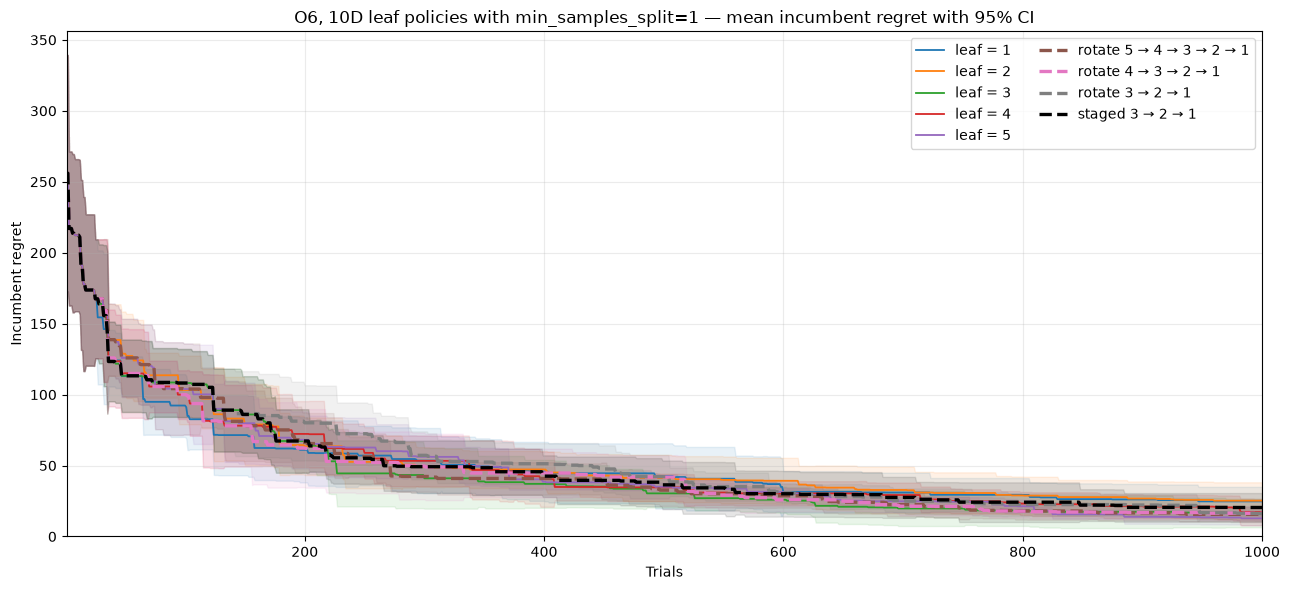

In [3]:
rows = [
    {"policy": policy, "seed": seed, "iteration": iteration, "best_regret": regret}
    for policy, runs in results.items()
    for seed, result in runs.items()
    for iteration, regret in zip(result["iteration"], result["best_regret"])
]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(13, 6))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    width = 2.4 if policy in ADAPTIVE else 1.3
    style = "--" if policy in ADAPTIVE else "-"
    ax.plot(data.iteration, data["mean"], label=LABELS[policy], color=COLORS[policy], linewidth=width, linestyle=style)
    ax.fill_between(data.iteration, np.maximum(0, data["mean"] - data.ci95), data["mean"] + data.ci95, color=COLORS[policy], alpha=.10)
ax.set(title="O6, 10D leaf policies with min_samples_split=1 — mean incumbent regret with 95% CI", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS), ylim=(0, None))
ax.grid(alpha=.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

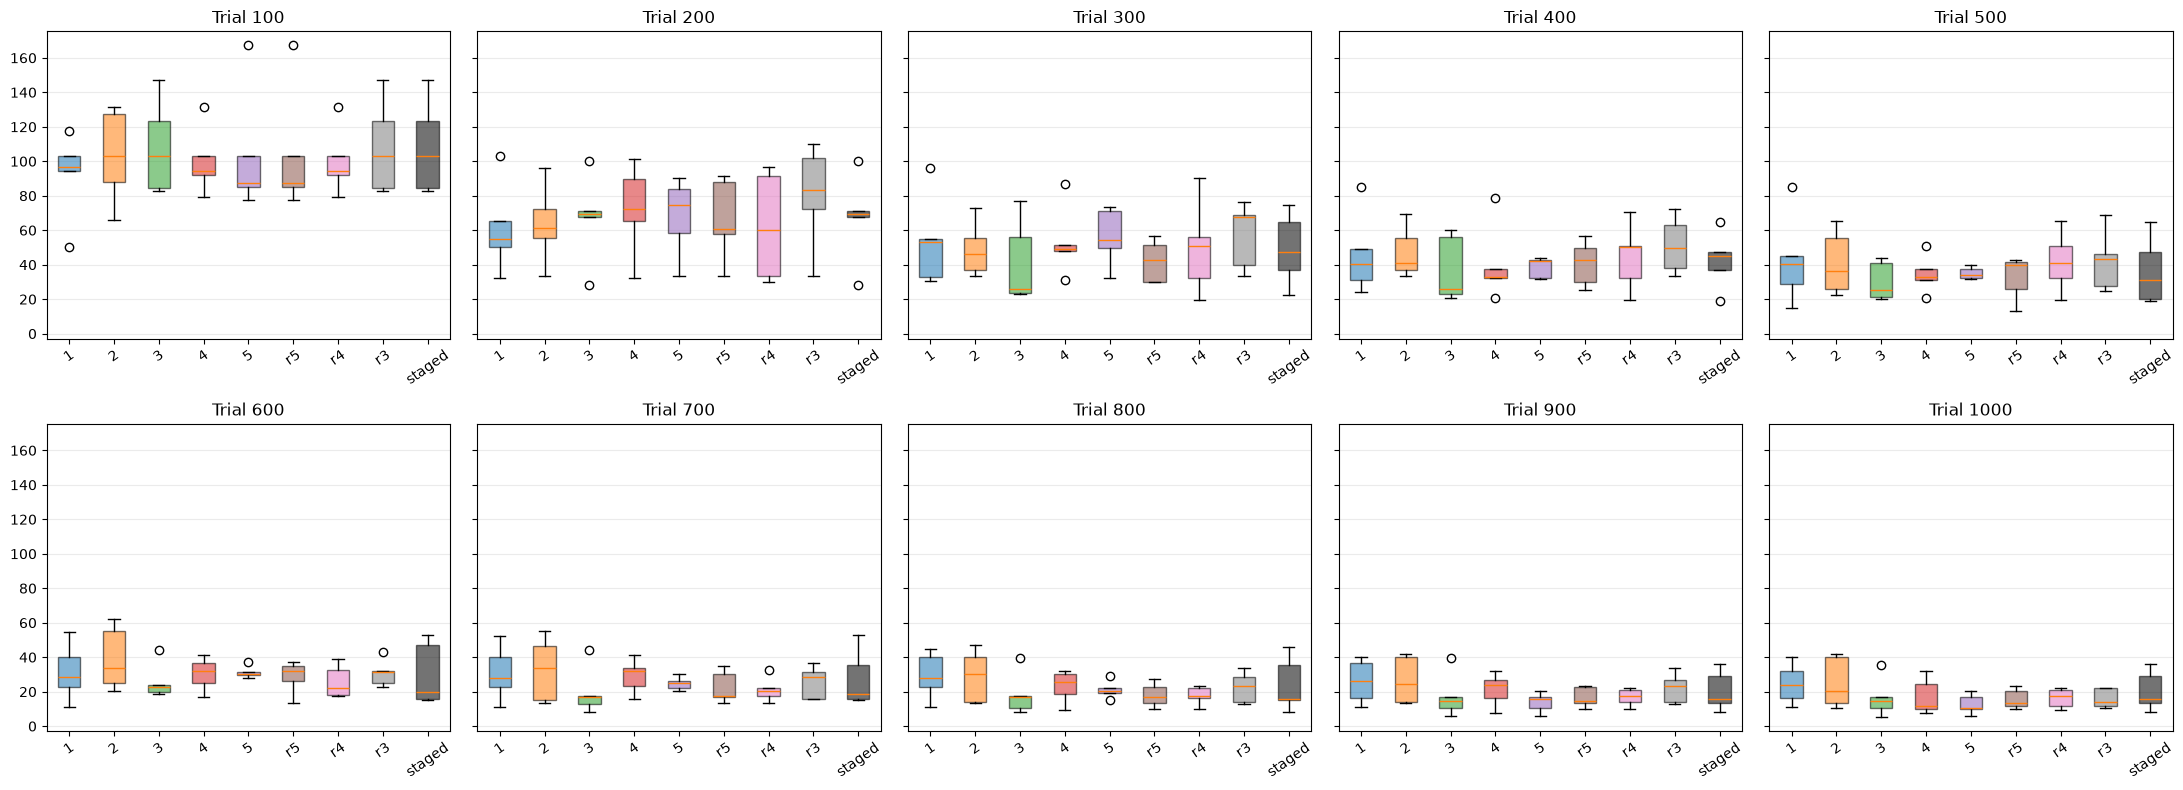

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS] for policy in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(leaf) for leaf in LEAF_SIZES] + ["r5", "r4", "r3", "staged"])
    for box, policy in zip(boxes["boxes"], POLICIES):
        box.set(facecolor=COLORS[policy], alpha=.55)
    ax.set_title(f"Trial {checkpoint}")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.show()

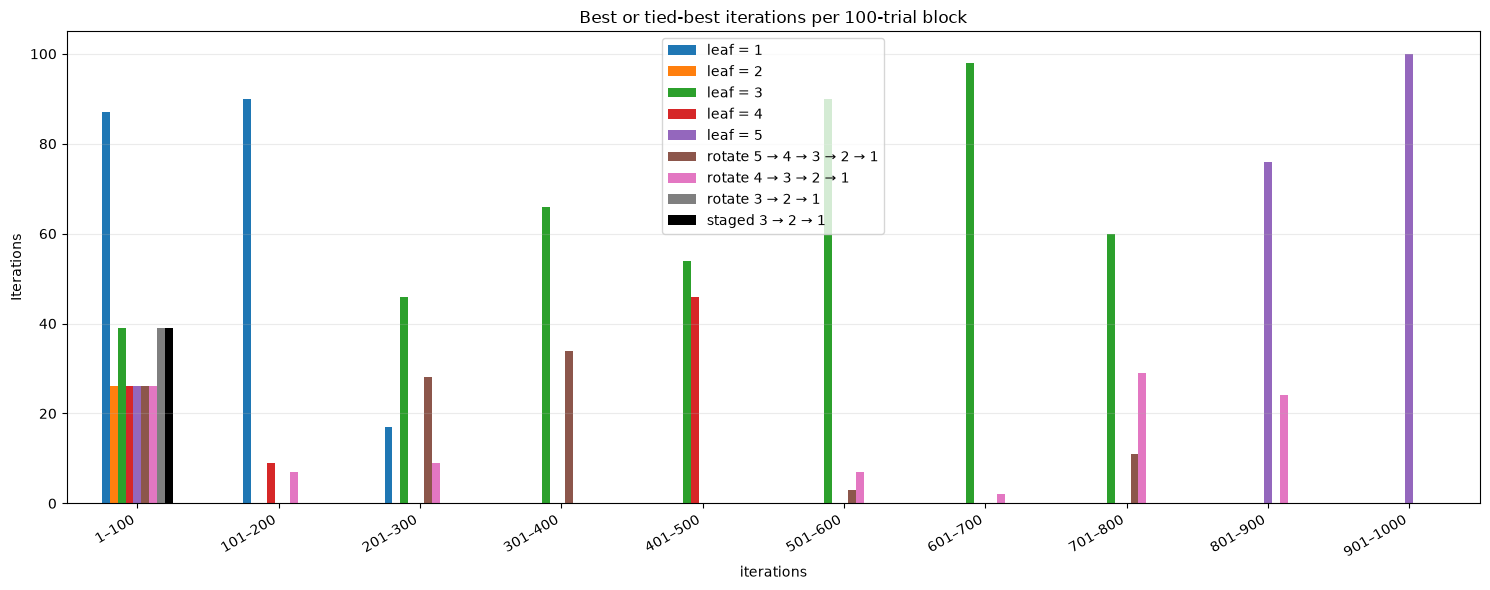

,iterations,superior policy,leaf = 1,leaf = 2,leaf = 3,leaf = 4,leaf = 5,rotate 5 → 4 → 3 → 2 → 1,rotate 4 → 3 → 2 → 1,rotate 3 → 2 → 1,staged 3 → 2 → 1
0,1–100,leaf = 1,87,26,39,26,26,26,26,39,39
1,101–200,leaf = 1,90,0,0,9,0,0,7,0,0
2,201–300,leaf = 3,17,0,46,0,0,28,9,0,0
3,301–400,leaf = 3,0,0,66,0,0,34,0,0,0
4,401–500,leaf = 3,0,0,54,46,0,0,0,0,0
5,501–600,leaf = 3,0,0,90,0,0,3,7,0,0
6,601–700,leaf = 3,0,0,98,0,0,0,2,0,0
7,701–800,leaf = 3,0,0,60,0,0,11,29,0,0
8,801–900,leaf = 5,0,0,0,0,76,0,24,0,0
9,901–1000,leaf = 5,0,0,0,0,100,0,0,0,0


In [5]:
mean_regret = trajectories.pivot_table(index="iteration", columns="policy", values="best_regret", aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({policy: np.isclose(mean_regret[policy], best, rtol=1e-12, atol=1e-9) for policy in POLICIES}, index=mean_regret.index)
block_rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum()
    maximum = int(counts.max())
    row = {"iterations": f"{end - 99}–{end}", "superior policy": ", ".join(LABELS[policy] for policy in POLICIES if counts[policy] == maximum)}
    row.update({LABELS[policy]: int(counts[policy]) for policy in POLICIES})
    block_rows.append(row)
block_superiority = pd.DataFrame(block_rows)
ax = block_superiority.set_index("iterations")[[LABELS[policy] for policy in POLICIES]].plot(kind="bar", figsize=(15, 6), color=[COLORS[policy] for policy in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block", ylabel="Iterations", ylim=(0, 105))
ax.grid(axis="y", alpha=.25)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(block_superiority)

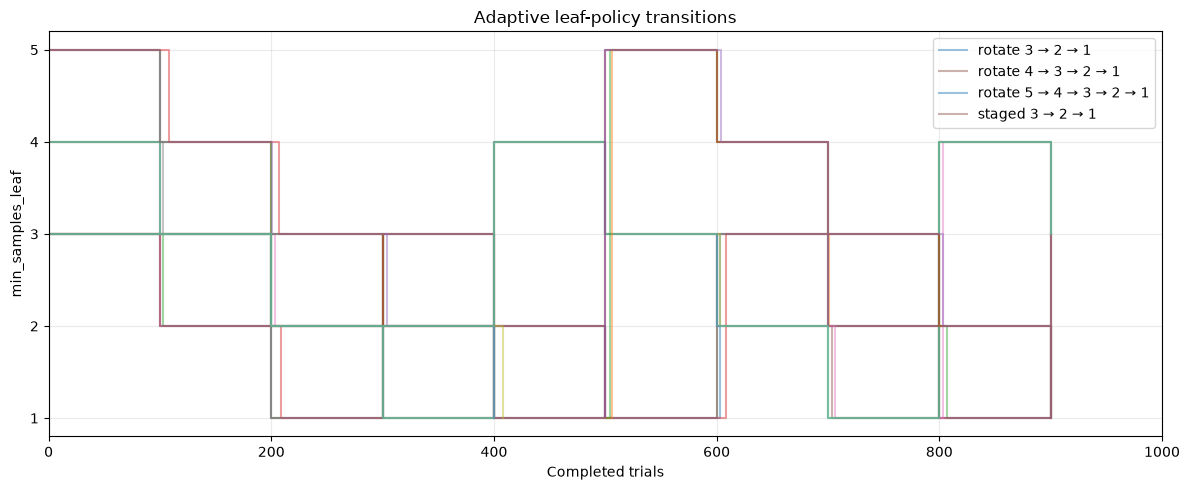

,policy,seed,completed_trials,leaf
0,rotate 5 → 4 → 3 → 2 → 1,3,0,5
1,rotate 5 → 4 → 3 → 2 → 1,3,108,4
2,rotate 5 → 4 → 3 → 2 → 1,3,207,3
3,rotate 5 → 4 → 3 → 2 → 1,3,300,2
4,rotate 5 → 4 → 3 → 2 → 1,3,400,1
...,...,...,...,...
160,staged 3 → 2 → 1,1,200,2
161,staged 3 → 2 → 1,1,400,1
162,staged 3 → 2 → 1,0,0,3
163,staged 3 → 2 → 1,0,200,2


In [6]:
transition_rows = []
for policy in ADAPTIVE:
    for seed, result in results[policy].items():
        for completed_trials, leaf in result["transitions"]:
            transition_rows.append({"policy": LABELS[policy], "seed": seed, "completed_trials": completed_trials, "leaf": leaf})
transitions = pd.DataFrame(transition_rows)
fig, ax = plt.subplots(figsize=(12, 5))
for (policy, seed), data in transitions.groupby(["policy", "seed"]):
    ax.step(data.completed_trials, data.leaf, where="post", alpha=.45, label=policy if seed == 0 else None)
ax.set(title="Adaptive leaf-policy transitions", xlabel="Completed trials", ylabel="min_samples_leaf", yticks=LEAF_SIZES, xlim=(0, N_TRIALS))
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.show()
transitions

In [7]:
run_rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        regret = np.asarray(result["best_regret"], dtype=float)
        run_rows.append({"policy": LABELS[policy], "seed": seed, "final_regret": regret[-1], "mean_incumbent_regret": regret.mean()})
run_metrics = pd.DataFrame(run_rows)
metric_summary = run_metrics.groupby("policy")[["final_regret", "mean_incumbent_regret"]].agg(["mean", "std", "median", "min", "max"]).sort_values(("final_regret", "mean"))
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(metric_summary)
    display(run_metrics.sort_values(["seed", "final_regret"]))

final_regret                                   \
                                 mean        std     median        min   
policy                                                                   
leaf = 5                    12.802061   5.670386  10.672300   6.152746   
rotate 5 → 4 → 3 → 2 → 1    15.623285   5.745475  13.337684   9.711949   
rotate 3 → 2 → 1            16.159972   5.642707  14.270863  10.690045   
rotate 4 → 3 → 2 → 1        16.339089   5.612432  17.589362   9.371333   
leaf = 3                    16.512947  11.440952  14.428429   5.299086   
leaf = 4                    17.197626  10.581539  11.876539   7.651986   
staged 3 → 2 → 1            20.446781  11.610159  15.709372   8.036359   
leaf = 1                    24.737037  11.682924  23.948190  11.315319   
leaf = 2                    25.217604  14.824832  20.265416  10.686247   

                                    mean_incumbent_regret             \
                                max                  mean        std   
policy                                                                 
leaf = 5                  20.389112             48.618272   9.491458   
rotate 5 → 4 → 3 → 2 → 1  23.083481             46.897400  10.504225   
rotate 3 → 2 → 1          22.414005             52.926610  14.399887   
rotate 4 → 3 → 2 → 1      22.018289             46.550853  12.182521   
leaf = 3                  35.455182             44.974937  13.840305   
leaf = 4                  31.999328             49.086558  14.028262   
staged 3 → 2 → 1          35.901340             49.699434  15.913821   
leaf = 1                  40.318638             50.596773  18.513196   
leaf = 2                  42.008950             53.147518  17.065192   

                                                           
                             median        min        max  
policy                                                     
leaf = 5                  48.255887  35.944525  58.810001  
rotate 5 → 4 → 3 → 2 → 1  48.607137  30.745188  60.084256  
rotate 3 → 2 → 1          58.851471  34.526412  66.980209  
rotate 4 → 3 → 2 → 1      47.762412  33.125269  58.602850  
leaf = 3                  40.408770  30.859581  61.275677  
leaf = 4                  48.361955  29.942925  65.881121  
staged 3 → 2 → 1          55.250446  29.763913  69.522365  
leaf = 1                  45.939360  30.551218  79.349200  
leaf = 2                  45.920674  32.833603  73.449905

,policy,seed,final_regret,mean_incumbent_regret
24,leaf = 5,0,6.152746,35.944525
19,leaf = 4,0,7.651986,29.942925
4,leaf = 1,0,11.315319,30.551218
34,rotate 4 → 3 → 2 → 1,0,11.687537,35.084633
9,leaf = 2,0,13.187518,32.833603
29,rotate 5 → 4 → 3 → 2 → 1,0,13.337684,30.745188
44,staged 3 → 2 → 1,0,13.468949,29.763913
39,rotate 3 → 2 → 1,0,14.270863,34.526412
14,leaf = 3,0,14.428429,30.859581
13,leaf = 3,1,5.299086,40.408770


In [8]:
checkpoint_table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration", "policy"])["best_regret"].agg(["mean", "std", "min", "median", "max"])
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(checkpoint_table)

mean        std        min  \
iteration policy                                                              
100       fixed_leaf_1                      92.299009  25.252416  50.215903   
          fixed_leaf_2                     103.232969  27.582409  65.691130   
          fixed_leaf_3                     108.159702  27.374557  82.534547   
          fixed_leaf_4                      99.957901  19.573054  79.329201   
          fixed_leaf_5                     103.923077  36.638681  77.261918   
          rotate_leaf_3_2_1_every_100      108.159702  27.374557  82.534547   
          rotate_leaf_4_3_2_1_every_100     99.957901  19.573054  79.329201   
          rotate_leaf_5_4_3_2_1_every_100  103.923077  36.638681  77.261918   
          staged_leaf_3_2_1_200_200_rest   108.159702  27.374557  82.534547   
200       fixed_leaf_1                      61.092169  26.251310  32.397601   
          fixed_leaf_2                      63.584673  23.149384  33.198932   
          fixed_leaf_3                      67.294187  25.525637  28.332721   
          fixed_leaf_4                      72.295071  26.397993  32.446592   
          fixed_leaf_5                      68.142393  22.918443  33.198932   
          rotate_leaf_3_2_1_every_100       80.127992  30.189217  33.198932   
          rotate_leaf_4_3_2_1_every_100     62.272626  31.363208  29.777146   
          rotate_leaf_5_4_3_2_1_every_100   66.328716  24.121453  33.198932   
          staged_leaf_3_2_1_200_200_rest    67.294187  25.525637  28.332721   
300       fixed_leaf_1                      53.496696  26.214240  30.761603   
          fixed_leaf_2                      48.978327  15.921015  33.198932   
          fixed_leaf_3                      41.006854  24.405855  22.895056   
          fixed_leaf_4                      53.333418  20.387158  31.382106   
          fixed_leaf_5                      56.197936  16.840577  32.368118   
          rotate_leaf_3_2_1_every_100       57.197568  19.267315  33.198932   
          rotate_leaf_4_3_2_1_every_100     49.722474  26.829396  19.578379   
          rotate_leaf_5_4_3_2_1_every_100   42.282320  12.199228  30.102390   
          staged_leaf_3_2_1_200_200_rest    49.140729  21.053303  22.248416   
400       fixed_leaf_1                      45.893461  23.735108  23.968782   
          fixed_leaf_2                      47.250853  14.930587  33.198932   
          fixed_leaf_3                      37.113043  19.286737  20.755319   
          fixed_leaf_4                      40.378820  22.157881  20.818511   
          fixed_leaf_5                      38.594411   6.073874  31.638170   
          rotate_leaf_3_2_1_every_100       51.282167  16.537598  33.198932   
          rotate_leaf_4_3_2_1_every_100     44.731145  19.581144  19.578379   
          rotate_leaf_5_4_3_2_1_every_100   40.909297  13.058844  25.538574   
          staged_leaf_3_2_1_200_200_rest    42.534037  16.715777  18.876497   
500       fixed_leaf_1                      42.691488  26.253780  14.851948   
          fixed_leaf_2                      41.232488  18.630307  22.549730   
          fixed_leaf_3                      30.403302  11.370824  19.958644   
          fixed_leaf_4                      34.603292  11.023727  20.818511   
          fixed_leaf_5                      35.038522   3.447854  31.638170   
          rotate_leaf_3_2_1_every_100       42.153083  17.483498  24.955463   
          rotate_leaf_4_3_2_1_every_100     41.825534  17.559349  19.578379   
          rotate_leaf_5_4_3_2_1_every_100   32.677311  12.704952  13.337684   
          staged_leaf_3_2_1_200_200_rest    36.396061  19.573212  18.876497   
600       fixed_leaf_1                      31.483771  16.661252  11.315319   
          fixed_leaf_2                      39.247079  18.478931  20.474582   
          fixed_leaf_3                      25.931062  10.400082  18.782561   
          fixed_leaf_4                      30.414613   9.807883  16.683553   
          fixed_leaf